# 04 Gradient-based Sensitivity

This notebook reproduces the sensitivity style from the screenshots:

- Train a compact surrogate model on tabular features.
- Compute absolute input gradients on a held-out test batch.
- Plot feature-wise gradient distributions as log-scale boxplots.

Source inspiration: www.youtube.com/watch?v=5vsLmM756LA

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

root = Path.cwd()
sys.path.append(str(root / 'training'))
import nnue_lab_common as c

sns.set_theme(style='whitegrid')
device = c.device()
print('device:', device)

device: mps


In [4]:
def build_tabular(path, max_entries=90000, stride=10):
    rows = []
    with open(path, 'rb') as f:
        i = 0
        while len(rows) < max_entries:
            raw = f.read(c.ENTRY_SIZE)
            if not raw:
                break
            if i % stride == 0:
                p = c.parse_entry(raw)
                pc = p['piece_counts']
                rows.append([
                    pc[0], pc[1], pc[2], pc[3], pc[4],
                    pc[5], pc[6], pc[7], pc[8], pc[9],
                    p['stm'], p['pieces'],
                    len(p['white_feats']), len(p['black_feats']),
                ])
            i += 1

    labels = [
        '#pawns_w', '#knights_w', '#bishops_w', '#rooks_w', '#queens_w',
        '#pawns_b', '#knights_b', '#bishops_b', '#rooks_b', '#queens_b',
        'stm', '#pieces_total', '#white_feat', '#black_feat',
    ]
    X = pd.DataFrame(rows, columns=labels)

    mat = (
        3.4 * (X['#queens_w'] - X['#queens_b'])
        + 1.9 * (X['#rooks_w'] - X['#rooks_b'])
        + 1.2 * (X['#bishops_w'] - X['#bishops_b'])
        + 1.0 * (X['#knights_w'] - X['#knights_b'])
        + 0.23 * (X['#pawns_w'] - X['#pawns_b'])
    )
    phase = 0.12 * (X['#pieces_total'] - 20)
    activity = 0.05 * (X['#white_feat'] - X['#black_feat'])
    stm_term = np.where(X['stm'] > 0, -0.35, 0.35)
    y_series = np.clip(mat + phase + activity + stm_term + np.random.normal(0.0, 1.4, size=len(X)), -22, 22)
    y = np.asarray(y_series, dtype=np.float32)
    return X, y, labels

X_raw, y, LABELS = build_tabular(c.default_training_file())
split = int(0.2 * len(X_raw))
X_test_raw = X_raw.iloc[:split].copy()
X_train_raw = X_raw.iloc[split:].copy()
y_test = y[:split]
y_train = y[split:]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0).replace(0, 1.0)
X_train = ((X_train_raw - mu) / sigma).to_numpy(dtype=np.float32)
X_test = ((X_test_raw - mu) / sigma).to_numpy(dtype=np.float32)

class SensNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32), nn.LeakyReLU(),
            nn.Linear(32, 16), nn.LeakyReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)

model = SensNet(X_train.shape[1]).to(device)
opt = optim.Adam(model.parameters(), lr=2e-3)
criterion = nn.HuberLoss(delta=1.0)

Xt = torch.tensor(X_train, device=device)
yt = torch.tensor(y_train[:, None], device=device)
model.train()
for _ in range(6):
    order = torch.randperm(Xt.size(0), device=device)
    for start in range(0, Xt.size(0), 1024):
        idx = order[start:start + 1024]
        xb = Xt[idx]
        yb = yt[idx]
        pred = model(xb)
        loss = criterion(pred, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()

# Gradient sensitivity on test subset
model.eval()
subset = min(4096, len(X_test))
Xg = torch.tensor(X_test[:subset], device=device, requires_grad=True)
out = model(Xg).sum()
out.backward()
grad = Xg.grad.detach().abs().cpu().numpy()

def to_long(g, labels):
    parts = []
    for j, name in enumerate(labels):
        parts.append(pd.DataFrame({'feature': name, 'sensitivity': g[:, j] + 1e-7}))
    return pd.concat(parts, ignore_index=True)

long_df = to_long(grad, LABELS)
mid = len(LABELS) // 2
top_labels = LABELS[:mid]
bot_labels = LABELS[mid:]
long_top = long_df[long_df['feature'].isin(top_labels)]
long_bot = long_df[long_df['feature'].isin(bot_labels)]

print('Gradient samples:', grad.shape)
print('Median sensitivity:', float(np.median(grad)))

Gradient samples: (4096, 14)
Median sensitivity: 0.7059812545776367


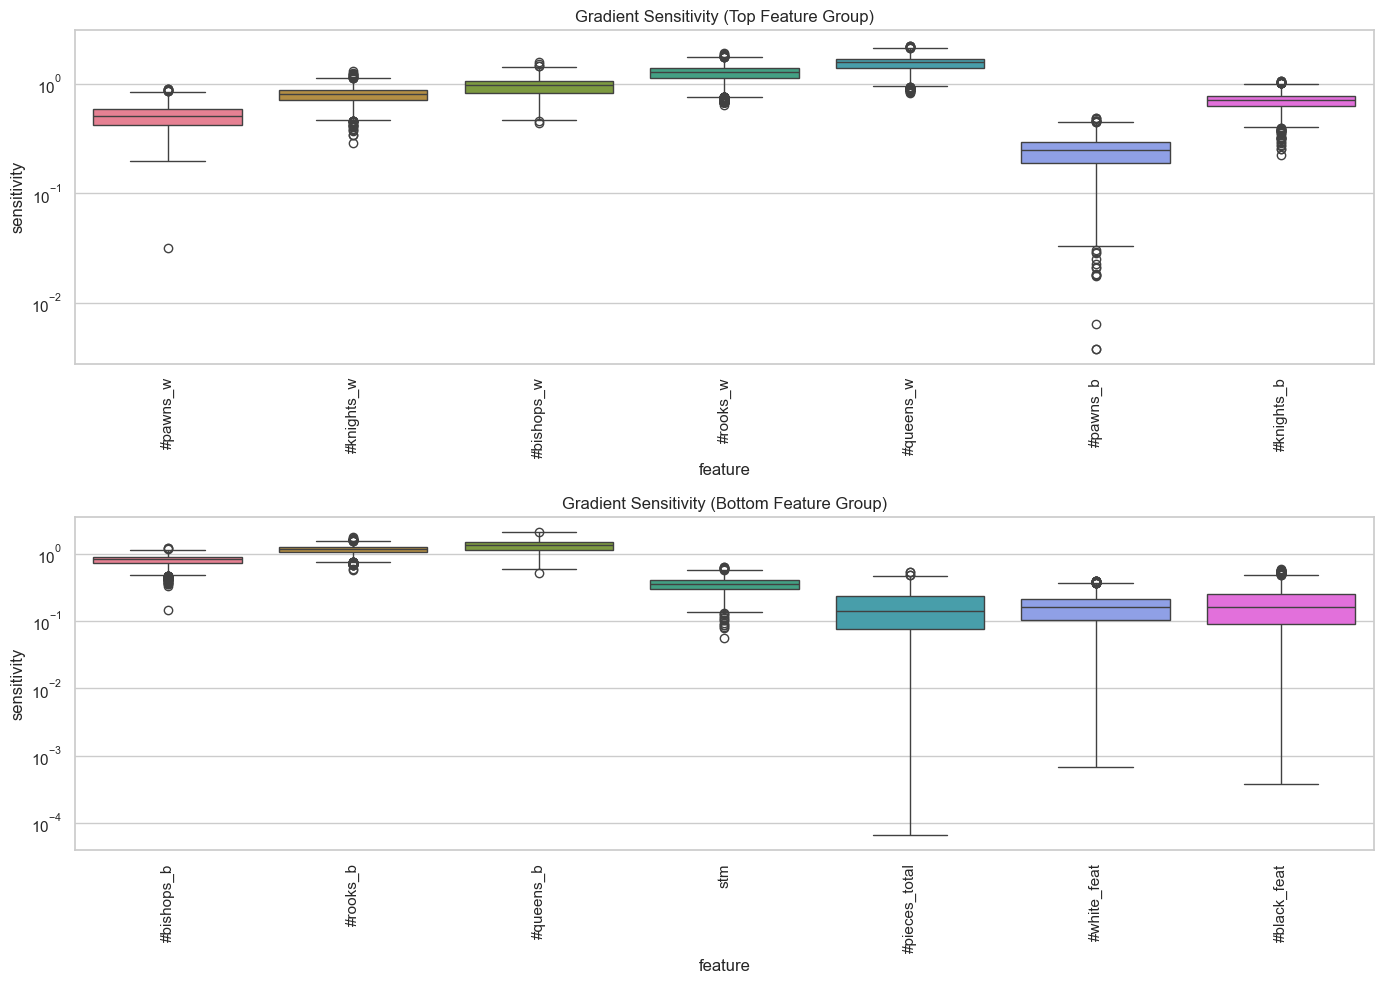

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

sns.boxplot(data=long_top, x='feature', y='sensitivity', hue='feature', ax=axes[0], palette='husl', legend=False)
axes[0].set_yscale('log')
axes[0].set_title('Gradient Sensitivity (Top Feature Group)')
axes[0].tick_params(axis='x', rotation=90)

sns.boxplot(data=long_bot, x='feature', y='sensitivity', hue='feature', ax=axes[1], palette='husl', legend=False)
axes[1].set_yscale('log')
axes[1].set_title('Gradient Sensitivity (Bottom Feature Group)')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()